# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [21]:
# Each filter accepts one value, a list of values, or None for every value.
NS = [2,3,4]                # e.g. 3 or [2, 3, 4]
LS = None                 # e.g. 2 or [1, 2, 3]
CIRCUITS = ["all_to_all_crx","block_crx","ring_trainable_crz","ghz_orbit","local_ry_rz"]           # e.g. "multiscale_tree" or ["default", "uni2"]
INITIAL_STATES = None     # e.g. "sine" or ["sine", "tapered_gaussian"]
MODES = None              # e.g. "noise_free" or ["variance", "gradient"]

runs = an.list_runs(
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    modes=MODES,
)
an.print_runs(runs)


 N  L            Circuit Initial state       Mode  Parameters  Saved  Variance
 2  4     all_to_all_crx          sine noise_free          14   True     False
 2  4          block_crx          sine noise_free          14   True     False
 2  4          ghz_orbit          sine noise_free          16   True     False
 2  4        local_ry_rz          sine noise_free          20   True     False
 2  4 ring_trainable_crz          sine noise_free          14   True     False
 3  4     all_to_all_crx          sine noise_free          27   True     False
 3  4          block_crx          sine noise_free          27   True     False
 3  4          ghz_orbit          sine noise_free          24   True     False
 3  4        local_ry_rz          sine noise_free          30   True     False
 3  4 ring_trainable_crz          sine noise_free          27   True     False
 4  4     all_to_all_crx          sine noise_free          44   True     False
 4  4          block_crx          sine noise_free   

In [248]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(n = 6, circuit="multiscale_tree", show_variants=False)


N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=6, L=2 | default_len=19 | default_mse=0.00034216808447705345
N=6, L=3 | default_len=25 | default_mse=0.00022093751229731567
N=6, L=4 | default_len=31 | default_mse=1.4132765958221204e-06
N=6, L=5 | default_len=37 | default_mse=2.6986324565342634e-06
N=6, L=6 | default_len=43 | default_mse=1.5119335353666355e-06
N=6, L=7 | default_len=49 | default_mse=1.4055003835099423e-07
N=6, L=8 | default_len=55 | default_mse=5.47238702094108e-07
count=8 presets


## Inspect one run


In [3]:
DIR_LABEL = "N5"
LABEL = "L5"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N5', label='L5', full_label='N5_L5', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/figures_L5'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N5/data_L5', 'dir_label': 'N5', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N5/figures_L5', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 5, 'label': 'L5', 'manifest_path': 'results/results_N5/manifest_N5_L5.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 5, 'n_timesteps': 28, 'n_total': 32, 'optimization_steps': 1000, 'pa

In [4]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/manifest_N5_L5.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5/values_N5_L5.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'expressibility', 'entangling_capability', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 5,
 'l': 5,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'expressibility': 0.12782413492695527,
 'entangling_capability': 0.8318029744040429,
 'initial_fit_mse': 1.0888691785137848e-08,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [17]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 21)
variance: None


In [18]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


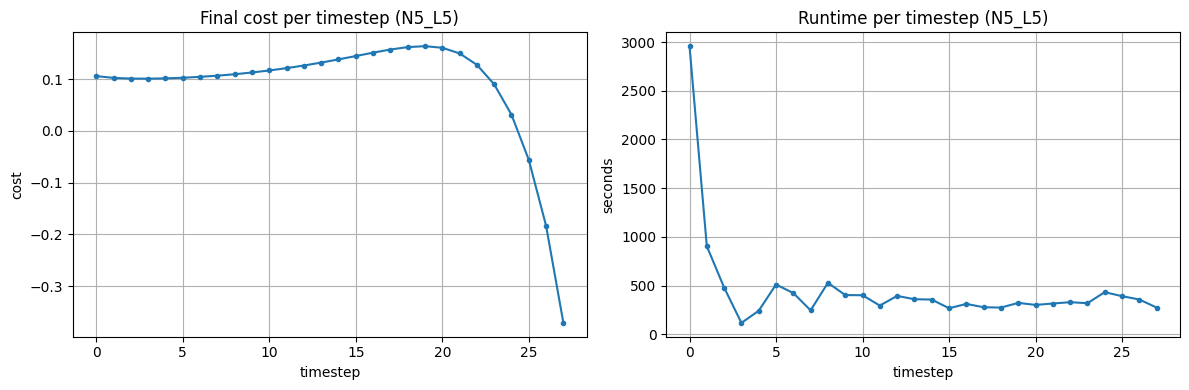

In [5]:
an.plot_costs_and_times(run);


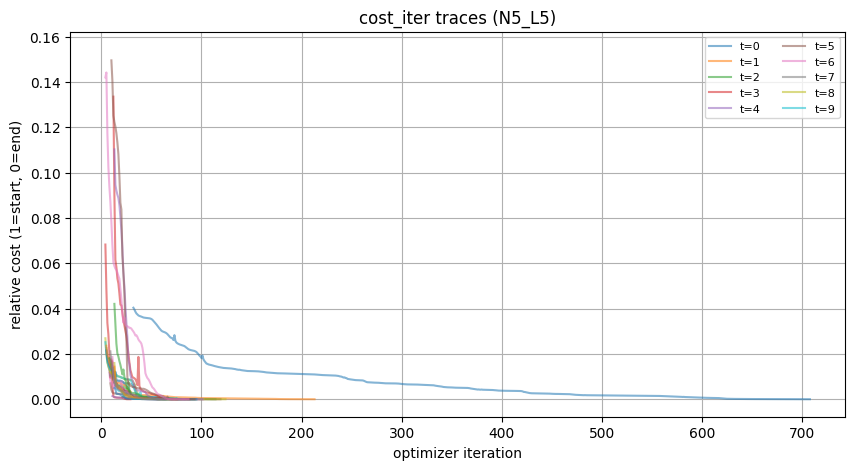

In [6]:
an.plot_cost_histories(
    run,
    normalize=True,
    remove_outliers=True,
    outlier_method="iqr",       # "iqr" or "percentile"
    outlier_factor=3.0,
    outlier_percentiles=(1.0, 99.0),
    show_first_n_labels=10,
);


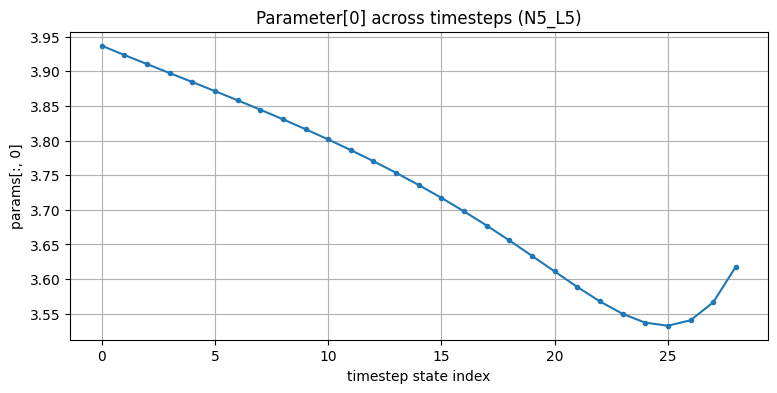

In [7]:
an.plot_parameter_history(run, parameter_index=0);


shots_used_total: 0


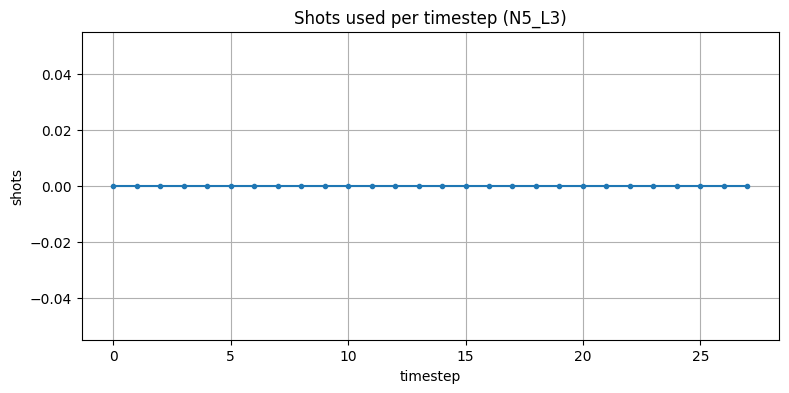

In [ ]:
an.plot_shots(run);

## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


In [269]:
DIR_LABEL = "N6"
LABEL = "L7"

run = an.load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='N6', label='L7', full_label='N6_L7', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6/data_L7'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6/figures_L7'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N6/data_L7', 'dir_label': 'N6', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 50000, 'fig_dir': 'results/results_N6/figures_L7', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 7, 'label': 'L7', 'manifest_path': 'results/results_N6/manifest_N6_L7.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 6, 'n_timesteps': 28, 'n_total': 64, 'optimization_steps': 1000, 'pat

timestep                       2.800000e+01
time                           2.800000e-01
MSE                            4.903054e-07
R2                             9.999985e-01
Fidelity                       9.999985e-01
RelativeL1Error                1.229239e-03
RelativeL2Error                1.244015e-03
RelativeLinfError              1.758105e-03
RelativeDerivativeL2Error      1.862334e-03
RelativeDerivativeLinfError    1.798700e-03
RelativeMassError                       NaN
NormalizedMassDrift            1.331206e+01
dtype: float64

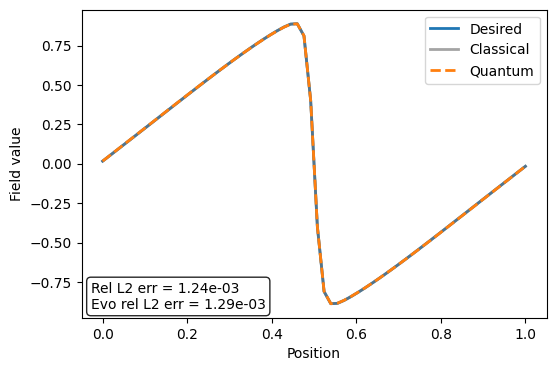

In [270]:
TIMESTEP = -1

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})


In [196]:
# fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

timestep                       2.800000e+01
time                           2.800000e-01
MSE                            2.238233e-07
R2                             9.999998e-01
Fidelity                       9.999998e-01
RelativeL1Error                5.374123e-04
RelativeL2Error                4.744568e-04
RelativeLinfError              3.920298e-04
RelativeDerivativeL2Error      6.060716e-04
RelativeDerivativeLinfError    5.297519e-04
RelativeMassError                       NaN
NormalizedMassDrift            5.683402e+00
dtype: float64

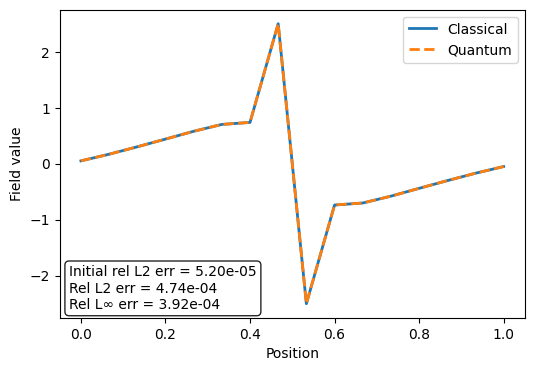

In [220]:
DIR_LABEL = "N4"
LABEL = "L4"

run = an.load_run(DIR_LABEL, LABEL)
TIMESTEP = -1

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})

## Classical and quantum fields over the whole time evolution

Choose `EVOLUTION_FIELDS = "classical"`, `"quantum"`, or `"both"`. Increase `TIMESTEP_STRIDE` to show fewer saved timesteps.


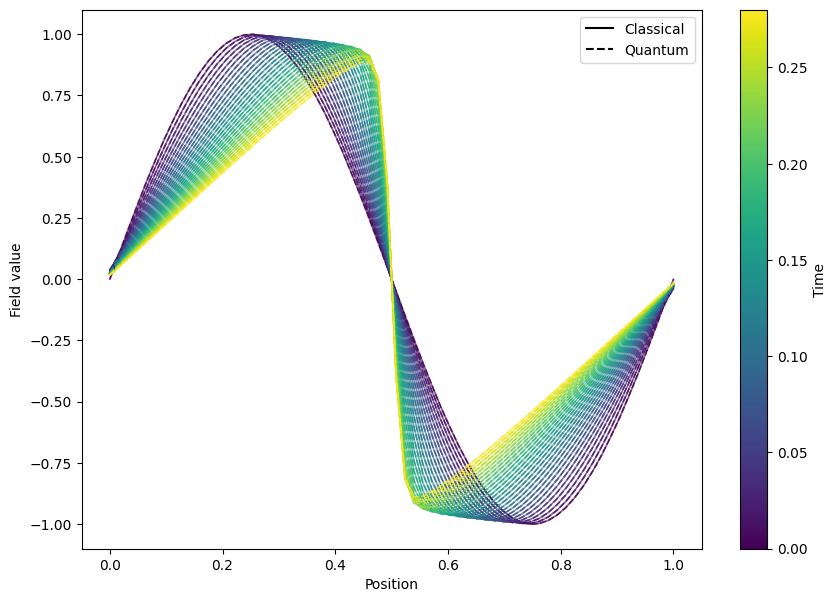

In [197]:
EVOLUTION_FIELDS = "both"       # "classical", "quantum", or "both"
TIMESTEP_STRIDE = 1             # 1 plots every saved timestep

evolution, evolution_ax, evolution_fig = an.plot_run_time_evolution(
    run,
    fields=EVOLUTION_FIELDS,
    timestep_stride=TIMESTEP_STRIDE,
)


In [198]:
evolution_fig.savefig(f"figures/single_runs/single_run_evolution_{DIR_LABEL}_{LABEL}_{EVOLUTION_FIELDS}_{TIMESTEP_STRIDE}.pdf", bbox_inches='tight')

## Expressibility and entangling capability


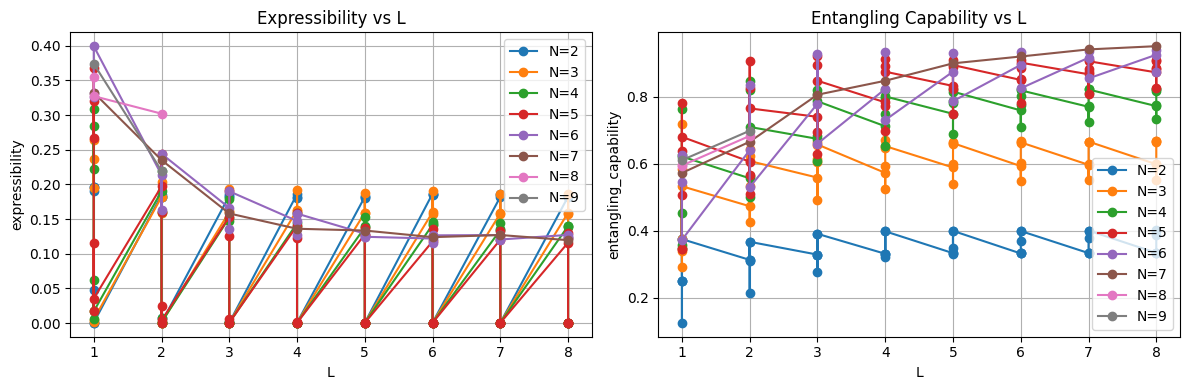

In [9]:
# Add (dir_label, label) pairs here. These select independently saved *_expr results.
# With an empty selection, discover *_expr results and full runs containing either metric.
EXPR_ENTCAP_SELECTION = []

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_expr_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = an.discover_expr_runs(include_full_runs=True)

if expr_runs:
    an.plot_expr_entcap_vs_l(expr_runs, n_filter=None)
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, the number of circuit parameters, legacy variance, gradient-run variances, expressibility, entangling capability, circuit, initial state, and final-state comparison metrics. `OverallGradientVariance` is the variance of the reconstructed total cost gradient, including the classical coefficients. `OverlapGradientVariance`, `AdvectionGradientVariance`, and `DiffusionGradientVariance` are calculated from the unscaled quantum combinations $dc_1$, $dc_4-dc_5$, and $dc_2-2dc_1+dc_3$, respectively. `Circuit1GradientVariance` through `Circuit5GradientVariance` are the variances of the five individual circuit derivatives $dc_1$ through $dc_5$. Gradient runs are matched exactly by `(N, L, Circuit, InitialState)`. Independently saved `exp_only` results are matched by `(N, L, Circuit)` and take priority over expressibility or entangling-capability values embedded in full simulation runs.

`InitialRelativeL2Error` measures the initial fit, `PropagatedInitialRelativeL2Error` compares the two classical trajectories initialized from the target and encoded fields, `EvolutionRelativeL2Error` compares the variational field with the classical trajectory initialized from the encoded field, and the existing `RelativeL2Error` is the total end-to-end error. These three final-time errors use the target classical field norm as their common denominator. Field derivatives use the simulation's periodic centered difference and mass uses $M=\Delta x\sum_i u_i$. Relative mass values are `NaN` when their reference mass is effectively zero. Leave `RUN_SELECTION` empty to select every available non-gradient simulation run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [3]:
RUN_SELECTION = [
    # ("N3", "L2"),
    # ("N4", "L3"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Optional explicit gradient selection. Leave empty to use all discovered gradient runs.
GRADIENT_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)
gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_SELECTION]
    if GRADIENT_SELECTION
    else an.discover_gradient_runs()
)
expression_runs = an.discover_expr_runs(include_full_runs=False)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
    gradient_runs=gradient_runs,
    expression_runs=expression_runs,
)
run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:737: RuntimeWarning: overflow encountered in multiply
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:736: RuntimeWarning: invalid value encountered in subtract
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:736: RuntimeWarning: invalid value encountered in add
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:735: RuntimeWarning: invalid value encountered in add
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:737: RuntimeWarning: invalid value encountered in subtract
 

,Run,N,L,NumberOfParameters,Var,OverallGradientVariance,OverlapGradientVariance,AdvectionGradientVariance,DiffusionGradientVariance,Circuit1GradientVariance,...,RelativeL1Error,InitialRelativeL2Error,PropagatedInitialRelativeL2Error,EvolutionRelativeL2Error,RelativeL2Error,RelativeLinfError,RelativeDerivativeL2Error,RelativeDerivativeLinfError,RelativeMassError,NormalizedMassDrift
0,N2_L1,2,1,4,NaN,0.251164,0.061809,3.090476e-02,6.176328e-01,0.061809,...,0.000006,2.461031e-07,1.398127e-07,0.000005,0.000006,0.000006,0.000005,0.000007,NaN,85.453496
1,N2_L1_mixed_sine_modes,2,1,4,NaN,0.255604,0.062903,3.145140e-02,6.295642e-01,0.062903,...,0.000043,9.197203e-09,5.938174e-09,0.000040,0.000040,0.000040,0.000036,0.000040,NaN,10484.173573
2,N2_L1_positive_periodic_wave,2,1,4,NaN,0.251618,0.062817,8.313977e-03,1.681556e-01,0.062817,...,0.000171,6.093190e-08,5.066898e-08,0.000153,0.000153,0.000116,0.000352,0.000306,0.000043,0.000043
3,N2_L1_tapered_gaussian,2,1,4,NaN,0.248658,0.062263,3.124669e-02,1.231207e-01,0.062263,...,0.000719,1.716229e-07,1.445750e-07,0.000643,0.000643,0.000725,0.000632,0.000631,0.000415,0.000415
4,N2_L2,2,2,6,NaN,0.255494,0.062875,3.143759e-02,6.275192e-01,0.062875,...,0.000043,1.052074e-07,8.007352e-08,0.000044,0.000044,0.000059,0.000047,0.000061,NaN,254.837784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,N7_L4,7,4,35,NaN,0.007841,0.001975,7.614780e-08,1.318856e-07,0.001975,...,NaN,3.742942e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.052548
880,N7_L5,7,5,42,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.253052e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62175.059475
881,N7_L6,7,6,49,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.162061e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,759559.009362
882,N7_L7,7,7,56,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.964430e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117795.567084


### `run_table` values and available filters

Every column below is available to `plot_run_table` as `X` or `Y`; columns can also be used for `GROUP_BY` when grouping by that value is meaningful.

- **Run configuration:** `Run` (saved-run label), `N` (number of qubits), `L` (number of ansatz layers), `NumberOfParameters`, `Circuit`, and `InitialState`.
- **Variance data:** `Var` (legacy saved cost-gradient variance); `OverallGradientVariance` (reconstructed total cost-gradient variance); `OverlapGradientVariance` ($\operatorname{Var}(dc_1)$); `AdvectionGradientVariance` ($\operatorname{Var}(dc_4-dc_5)$); `DiffusionGradientVariance` ($\operatorname{Var}(dc_2-2dc_1+dc_3)$); and the five individual-circuit values `Circuit1GradientVariance`, `Circuit2GradientVariance`, `Circuit3GradientVariance`, `Circuit4GradientVariance`, and `Circuit5GradientVariance`, corresponding to $\operatorname{Var}(dc_1)$ through $\operatorname{Var}(dc_5)$.
- **Circuit characteristics:** `Expressibility` and `EntanglingCapability`.
- **Final-state comparisons:** `R2`, `Fidelity`, `MSE`, `RelativeL1Error`, `InitialRelativeL2Error`, `PropagatedInitialRelativeL2Error`, `EvolutionRelativeL2Error`, `RelativeL2Error`, `RelativeLinfError`, `RelativeDerivativeL2Error`, `RelativeDerivativeLinfError`, `RelativeMassError`, and `NormalizedMassDrift`.

**Initial states available in the discovered saved simulation runs:** `mixed_sine_modes`, `positive_periodic_wave`, `sine`, and `tapered_gaussian`.

**Circuits available in the discovered saved simulation runs:** `all_to_all_crx`, `block_crx`, `brickwork_ring_ry`, `default`, `ghz_orbit`, `local_ry_rz`, `multiscale_tree`, `ring_ry_rz`, `ring_trainable_crx`, `ring_trainable_crz`, and `uni2`.

The variance columns from gradient runs are `NaN` when no gradient run matches a table row's exact `(N, L, Circuit, InitialState)` configuration. To inspect the choices present after changing `RUN_SELECTION`, use `sorted(run_table["Circuit"].dropna().unique())` and `sorted(run_table["InitialState"].dropna().unique())`.


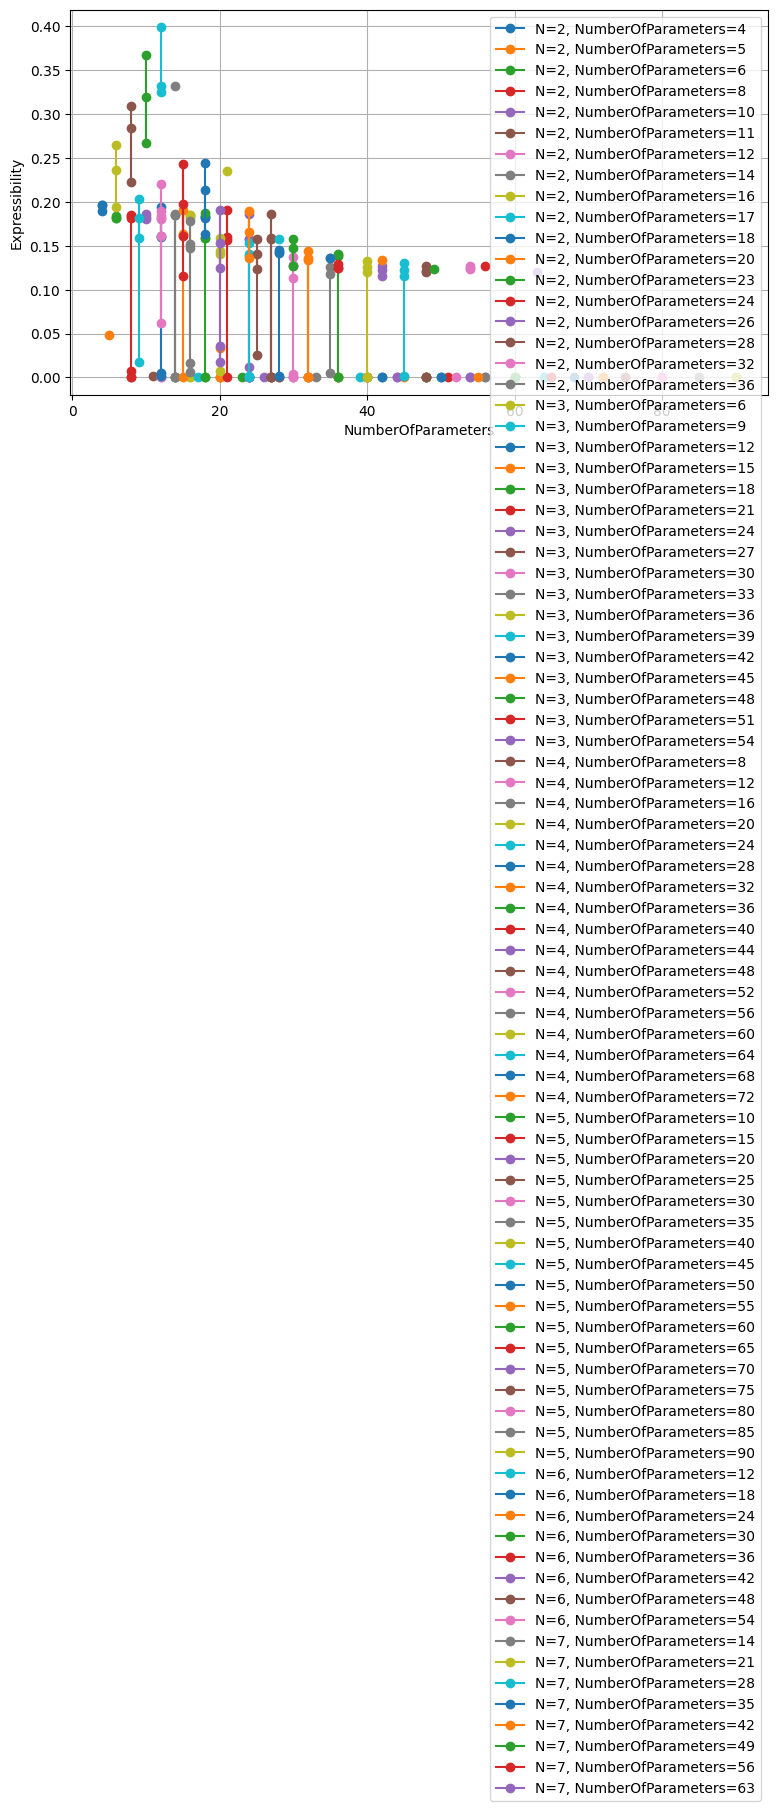

In [31]:
# X accepts one column; Y accepts one column or a list of columns.
# GROUP_BY accepts one column, a list of columns, or None.
X = "NumberOfParameters"
Y = "Expressibility"
GROUP_BY = ["N", "NumberOfParameters"] #["N", "Circuit"]
X_LABEL = None             # e.g. "Number of layers"; None uses X
Y_LABEL = None             # e.g. "Error"; None uses Y (or "Value" for multiple Ys)
X_LIMITS = None            # e.g. (0, 10); use None for automatic limits
Y_LIMITS = None            # e.g. (0, 1); use None for automatic limits

NS = None #[2,3,4,5,6] # None               # e.g. [3, 4, 5]
LS = None #[1,2,3,4,5,6,7,8]               # e.g. [1, 2, 3]
CIRCUITS = None #["ring_ry_rz","default","ring_trainable_crx","multiscale_tree"] #["uni2","ring_trainable_crx","default",'multiscale_tree']         # e.g. ["default", "uni2", "brickwork_ring_ry"]
INITIAL_STATES = "sine"   # e.g. ["sine", "tapered_gaussian"]

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    group_by=GROUP_BY,
    kind="line",        # "line" or "scatter"
    log_y=False,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
)
# filtered_table


In [ ]:
# folder = "exprs"
# name = "expr_default_default_all"
# fig.savefig(f"figures/{folder}/{name}.pdf", bbox_inches='tight')

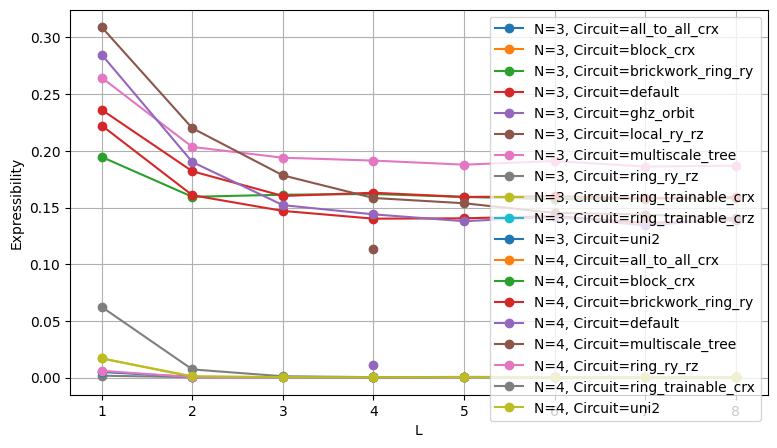

In [27]:
# X accepts one column; Y accepts one column or a list of columns.
# GROUP_BY accepts one column, a list of columns, or None.
X = "L"
Y = "Expressibility"
GROUP_BY = ["N","Circuit"]#["N", "NumberOfParameters"] #["N", "Circuit"]
X_LABEL = None             # e.g. "Number of layers"; None uses X
Y_LABEL = None             # e.g. "Error"; None uses Y (or "Value" for multiple Ys)
X_LIMITS = None            # e.g. (0, 10); use None for automatic limits
Y_LIMITS = None            # e.g. (0, 1); use None for automatic limits

NS = [3,4] #[2,3,4,5,6] # None               # e.g. [3, 4, 5]
LS = None #[1,2,3,4,5,6,7,8]               # e.g. [1, 2, 3]
CIRCUITS = None #["ring_ry_rz","default","ring_trainable_crx"] #["uni2","ring_trainable_crx","default",'multiscale_tree']         # e.g. ["default", "uni2", "brickwork_ring_ry"]
INITIAL_STATES = "sine"   # e.g. ["sine", "tapered_gaussian"]

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    group_by=GROUP_BY,
    kind="line",        # "line" or "scatter"
    log_y=False,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
)